<a href="https://colab.research.google.com/github/Mohamed-ktari/advanced-signal/blob/main/TPSA_EM_ViniciusBaiao_MohamedKtari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TPSA EM :   Vinicius Baiao and Mohamed Ktari

#TO DO 4

In [2]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# 1. Load the MATLAB file
data = sio.loadmat('img1.dat', appendmat=False)

# 2. Inspect the contents: loadmat returns a dict
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'P'])


Image shape : (50, 50)
Image dtype : float64
Min / Max   : -8.234372534697249 25.4458928293405
Vector shape: (2500,)
N = 2500 | rows*cols = 2500


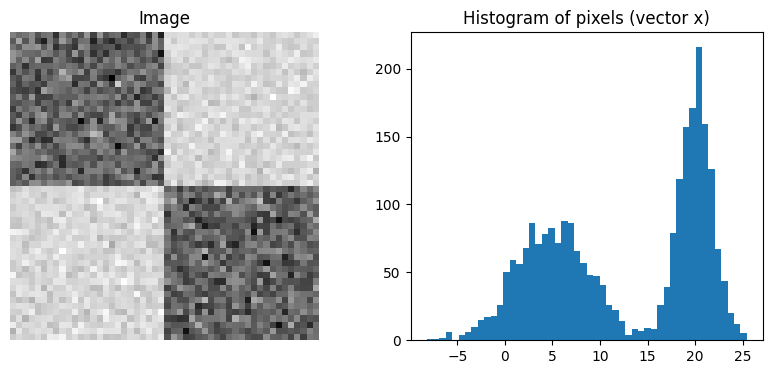

In [6]:
# 3. Extract the image matrix
img = data['P']

# 4. Check the matrix dimensions
print("Image shape :", img.shape)
print("Image dtype :", img.dtype)
print("Min / Max   :", img.min(), img.max())

# 5. Flatten the pixels into a vector x of N samples
x = img.reshape(-1)

# 6. Check the vector dimensions
print("Vector shape:", x.shape)        # (N,)
N = x.size
print("N =", N, "| rows*cols =", img.shape[0] * img.shape[1])
assert N == img.shape[0] * img.shape[1]

# 7. Visual check
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(x, bins=50)
plt.title('Histogram of pixels (vector x)')
plt.show()

In [7]:
import numpy as np

def pdfGauss(x, mu, sigma2):
    """
    Gaussian pdf of mean mu and variance sigma2, evaluated at each element of x.

    Inputs:
        x      : array of samples
        mu     : mean (scalar)
        sigma2 : variance (scalar, > 0)
    Output:
        p      : array of the same size as x
    """
    x = np.asarray(x, dtype=np.float64)
    p = np.exp(-(x - mu)**2 / (2 * sigma2)) / np.sqrt(2 * np.pi * sigma2)
    return p

In [9]:
import numpy as np

def algoEM(x, theta0, eps=1e-6, max_iter=500):
    """
    EM algorithm for a two-component 1D Gaussian mixture.

    Inputs:
        x      : array of N samples
        theta0 : initial parameters (pi1, pi2, mu1, mu2, var1, var2)
        eps    : precision for the stopping condition
        max_iter : safety limit on the number of iterations
    Output:
        theta_hist : array of shape (C+1, 6), row c = theta^(c)
                     columns: pi1, pi2, mu1, mu2, var1, var2
    """
    x = np.asarray(x, dtype=np.float64).ravel()
    N = x.size

    theta = np.array(theta0, dtype=np.float64)
    theta_hist = [theta.copy()]

    c = 0
    while c < max_iter:
        pi1, pi2, mu1, mu2, var1, var2 = theta

        # ---- Step E ----
        p1 = pi1 * pdfGauss(x, mu1, var1)
        p2 = pi2 * pdfGauss(x, mu2, var2)
        denom = p1 + p2
        t1 = p1 / denom
        t2 = p2 / denom

        # ---- Step M ----
        N1, N2 = t1.sum(), t2.sum()
        pi1_new, pi2_new = N1 / N, N2 / N
        mu1_new = np.sum(t1 * x) / N1
        mu2_new = np.sum(t2 * x) / N2
        var1_new = np.sum(t1 * (x - mu1_new)**2) / N1
        var2_new = np.sum(t2 * (x - mu2_new)**2) / N2

        theta_new = np.array([pi1_new, pi2_new, mu1_new, mu2_new, var1_new, var2_new])
        theta_hist.append(theta_new.copy())

        # ---- Stopping condition ----
        c += 1
        if np.linalg.norm(theta_new - theta) < eps:
            break
        theta = theta_new

    return np.array(theta_hist)

In [10]:

# theta0 = (pi1, pi2, mu1, mu2, var1, var2)
theta0 = [0.5, 0.5, x.min(), x.max(), x.var(), x.var()]

theta_hist = algoEM(x, theta0)

print("Iterations :", len(theta_hist) - 1)
print("theta0     :", theta_hist[0])
print("theta final:", theta_hist[-1])

Iterations : 19
theta0     : [ 0.5         0.5        -8.23437253 25.44589283 66.32733897 66.32733897]
theta final: [ 0.50030653  0.49969347  4.96905804 20.07603198 15.44509471  3.09172197]


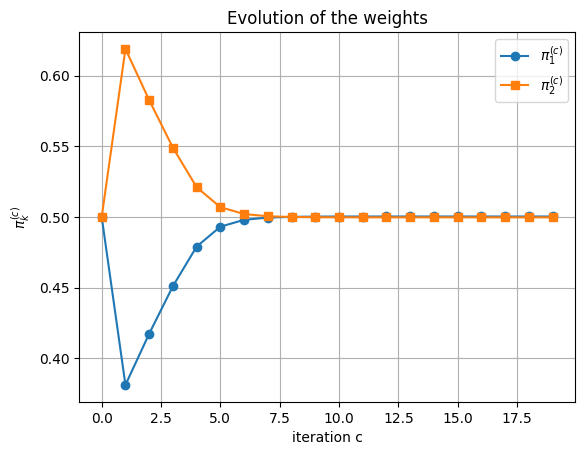

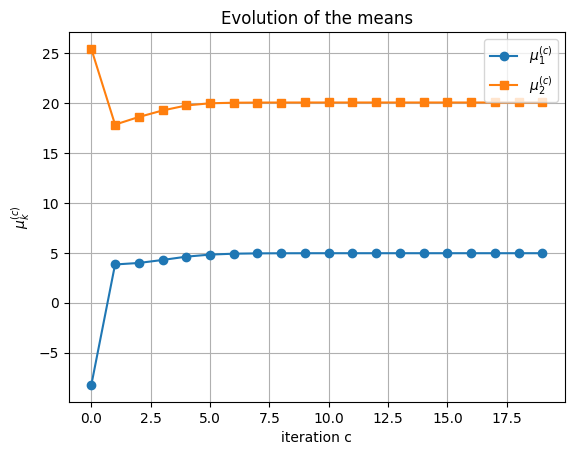

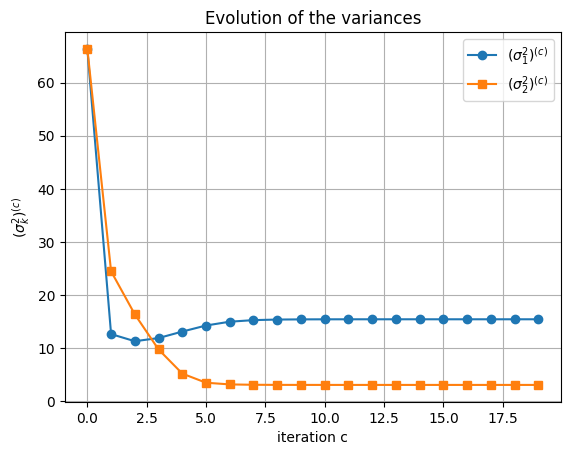

In [11]:
import matplotlib.pyplot as plt

C = np.arange(theta_hist.shape[0])   # iteration index c = 0, 1, ..., final

# Figure 1: weights pi_k
plt.figure()
plt.plot(C, theta_hist[:, 0], 'o-', label=r'$\pi_1^{(c)}$')
plt.plot(C, theta_hist[:, 1], 's-', label=r'$\pi_2^{(c)}$')
plt.xlabel('iteration c')
plt.ylabel(r'$\pi_k^{(c)}$')
plt.title('Evolution of the weights')
plt.legend()
plt.grid(True)

# Figure 2: means mu_k
plt.figure()
plt.plot(C, theta_hist[:, 2], 'o-', label=r'$\mu_1^{(c)}$')
plt.plot(C, theta_hist[:, 3], 's-', label=r'$\mu_2^{(c)}$')
plt.xlabel('iteration c')
plt.ylabel(r'$\mu_k^{(c)}$')
plt.title('Evolution of the means')
plt.legend()
plt.grid(True)

# Figure 3: variances sigma_k^2
plt.figure()
plt.plot(C, theta_hist[:, 4], 'o-', label=r'$(\sigma_1^2)^{(c)}$')
plt.plot(C, theta_hist[:, 5], 's-', label=r'$(\sigma_2^2)^{(c)}$')
plt.xlabel('iteration c')
plt.ylabel(r'$(\sigma_k^2)^{(c)}$')
plt.title('Evolution of the variances')
plt.legend()
plt.grid(True)

plt.show()

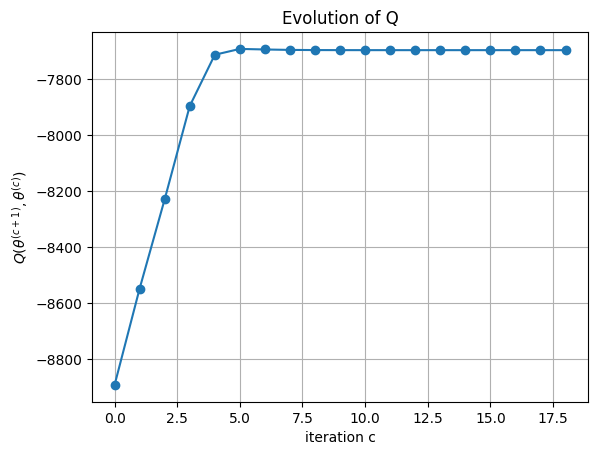

In [12]:
C_max = theta_hist.shape[0] - 1      # number of EM iterations
Q = np.zeros(C_max)

for c in range(C_max):

    pi1, pi2, mu1, mu2, var1, var2 = theta_hist[c]
    p1 = pi1 * pdfGauss(x, mu1, var1)
    p2 = pi2 * pdfGauss(x, mu2, var2)
    t1 = p1 / (p1 + p2)
    t2 = p2 / (p1 + p2)

    # theta^(c+1)
    pi1n, pi2n, mu1n, mu2n, var1n, var2n = theta_hist[c + 1]
    # ln of the Gaussian
    lg1 = -0.5*np.log(2*np.pi*var1n) - (x - mu1n)**2 / (2*var1n)
    lg2 = -0.5*np.log(2*np.pi*var2n) - (x - mu2n)**2 / (2*var2n)

    Q[c] = np.sum(t1 * (np.log(pi1n) + lg1)) + np.sum(t2 * (np.log(pi2n) + lg2))

plt.figure()
plt.plot(np.arange(C_max), Q, 'o-')
plt.xlabel('iteration c')
plt.ylabel(r'$Q(\theta^{(c+1)},\theta^{(c)})$')
plt.title('Evolution of Q')
plt.grid(True)
plt.show()

#TO DO 5

In [31]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
def load_image(path):
    if path.endswith('.dat'):
        d = sio.loadmat(path, appendmat=False)
        key = [k for k in d if not k.startswith('__')][0]
        img = d[key]
    else:
        img = mpimg.imread(path)
        if img.ndim == 3:
            img = img[..., :3].mean(axis=2)
    return np.asarray(img, dtype=np.float64)

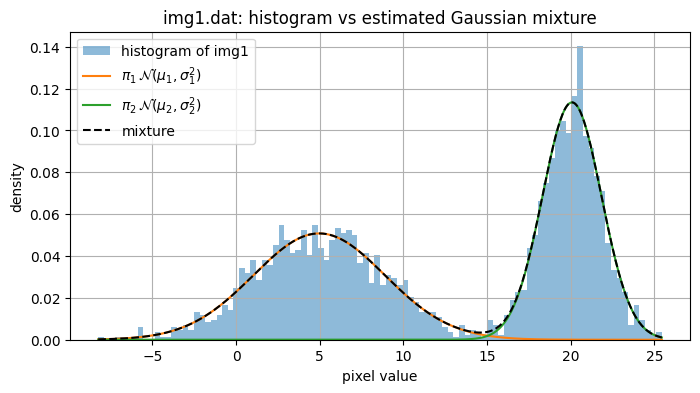

In [32]:
img = load_image('img1.dat')
x = img.reshape(-1)

# Run EM (use the theta0 you prefer)
s2 = x.var()
theta0 = [0.5, 0.5, np.percentile(x, 25), np.percentile(x, 75), s2, s2]
hist = algoEM(x, theta0, eps=1e-6)
pi1, pi2, mu1, mu2, v1, v2 = hist[-1]

# Grid on which to evaluate the pdfs
g = np.linspace(x.min(), x.max(), 500)
f1 = pi1 * pdfGauss(g, mu1, v1)
f2 = pi2 * pdfGauss(g, mu2, v2)

plt.figure(figsize=(8, 4))
plt.hist(x, bins=100, density=True, alpha=0.5, label='histogram of img1')
plt.plot(g, f1, label=r'$\pi_1\,\mathcal{N}(\mu_1,\sigma_1^2)$')
plt.plot(g, f2, label=r'$\pi_2\,\mathcal{N}(\mu_2,\sigma_2^2)$')
plt.plot(g, f1 + f2, 'k--', label='mixture')
plt.xlabel('pixel value')
plt.ylabel('density')
plt.title('img1.dat: histogram vs estimated Gaussian mixture')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
#experiment
def run(img, theta0, eps, title=''):
    x = img.reshape(-1)
    hist = algoEM(x, theta0, eps=eps)
    pi1, pi2, mu1, mu2, v1, v2 = hist[-1]


    p1 = pi1 * pdfGauss(x, mu1, v1)
    p2 = pi2 * pdfGauss(x, mu2, v2)
    labels = (p2 > p1).reshape(img.shape)

    print(f"{title} | eps={eps:g} | iters={len(hist)-1} | "
          f"pi=({pi1:.3f},{pi2:.3f}) mu=({mu1:.3f},{mu2:.3f}) var=({v1:.4f},{v2:.4f})")
    return hist, labels

In [42]:
images = {'img1.dat': load_image('img1.dat'),
          'img2.png': load_image('img2.png')}

for name, im in images.items():
    print(name, im.shape, im.min(), im.max())

img1.dat (50, 50) -8.234372534697249 25.4458928293405
img2.png (256, 256) 0.019607843831181526 1.0


img1.dat / extremes | eps=1e-06 | iters=19 | pi=(0.500,0.500) mu=(4.969,20.076) var=(15.4451,3.0917)
img1.dat / percentiles | eps=1e-06 | iters=17 | pi=(0.500,0.500) mu=(4.969,20.076) var=(15.4451,3.0917)
img1.dat / unbalanced | eps=1e-06 | iters=16 | pi=(0.500,0.500) mu=(4.969,20.076) var=(15.4451,3.0917)
img1.dat / one mode | eps=1e-06 | iters=98 | pi=(0.500,0.500) mu=(4.969,20.076) var=(15.4451,3.0917)
img1.dat / swapped | eps=1e-06 | iters=19 | pi=(0.500,0.500) mu=(20.076,4.969) var=(3.0917,15.4451)


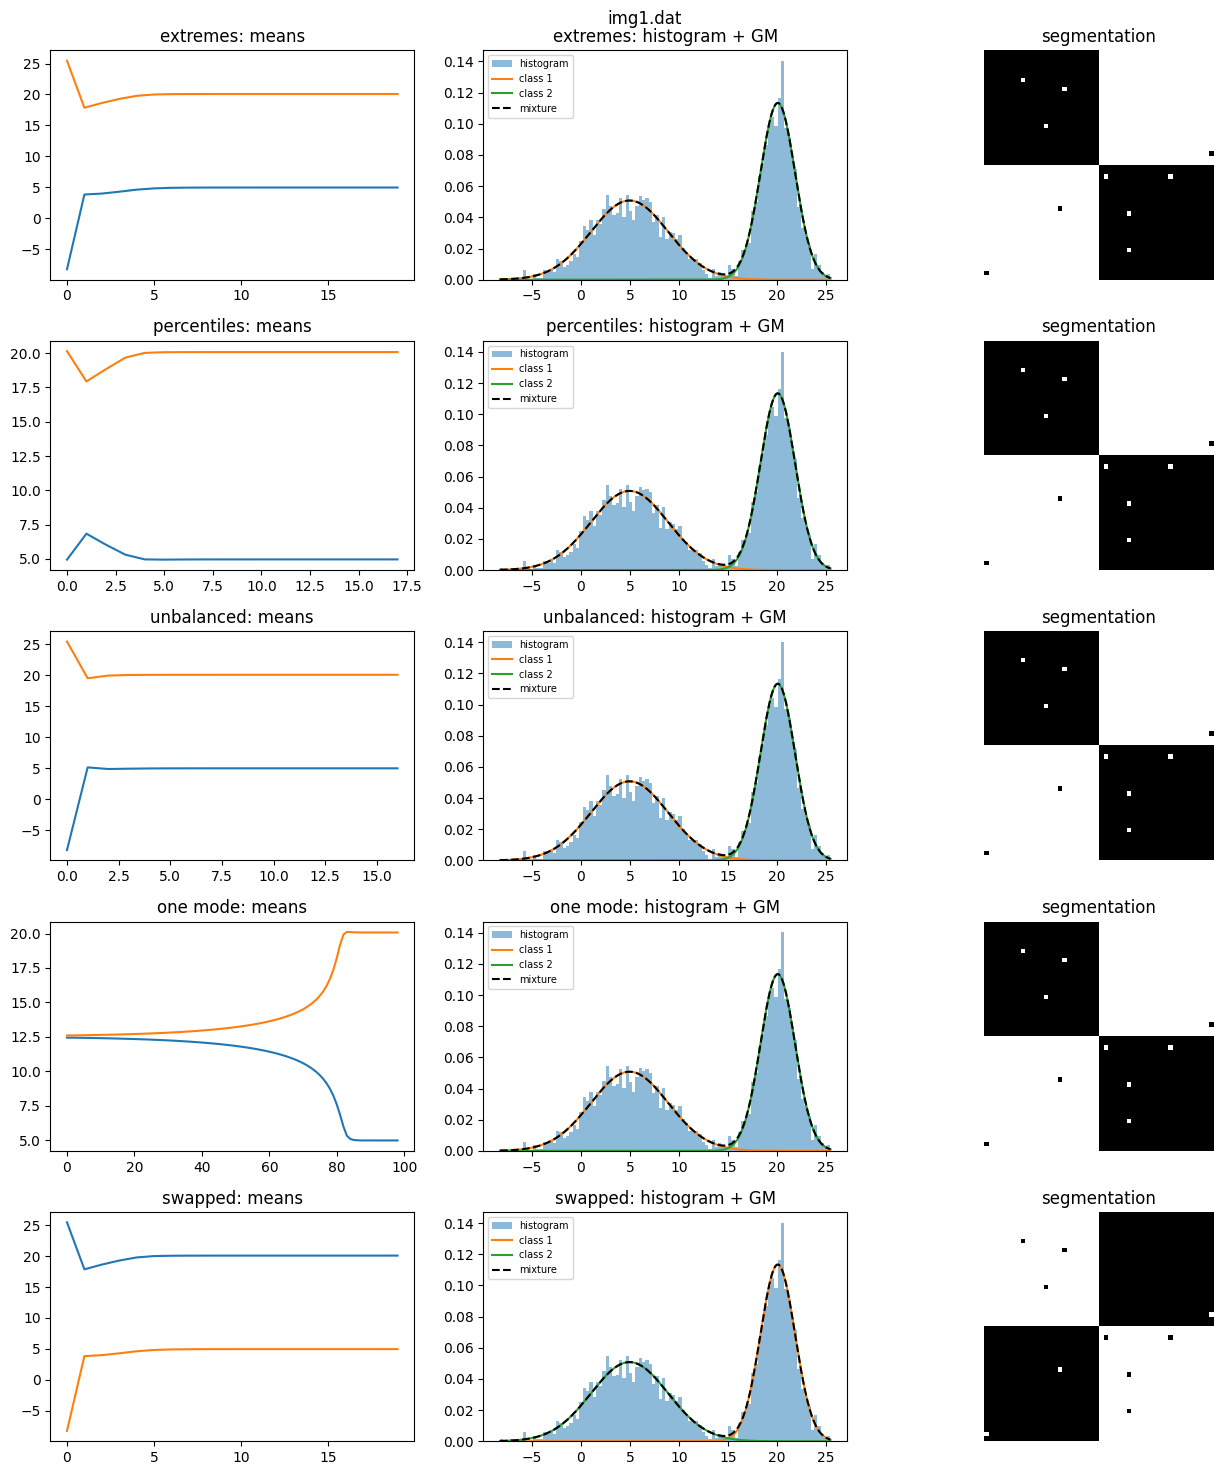

img1.dat / percentiles | eps=0.01 | iters=9 | pi=(0.500,0.500) mu=(4.969,20.076) var=(15.4429,3.0921)
img1.dat / percentiles | eps=0.0001 | iters=13 | pi=(0.500,0.500) mu=(4.969,20.076) var=(15.4451,3.0917)
img1.dat / percentiles | eps=1e-08 | iters=21 | pi=(0.500,0.500) mu=(4.969,20.076) var=(15.4451,3.0917)
img2.png / extremes | eps=1e-06 | iters=30 | pi=(0.405,0.595) mu=(0.315,0.865) var=(0.0195,0.0121)
img2.png / percentiles | eps=1e-06 | iters=34 | pi=(0.405,0.595) mu=(0.315,0.865) var=(0.0195,0.0121)
img2.png / unbalanced | eps=1e-06 | iters=34 | pi=(0.405,0.595) mu=(0.315,0.865) var=(0.0195,0.0121)
img2.png / one mode | eps=1e-06 | iters=71 | pi=(0.405,0.595) mu=(0.315,0.865) var=(0.0195,0.0121)
img2.png / swapped | eps=1e-06 | iters=30 | pi=(0.595,0.405) mu=(0.865,0.315) var=(0.0121,0.0195)


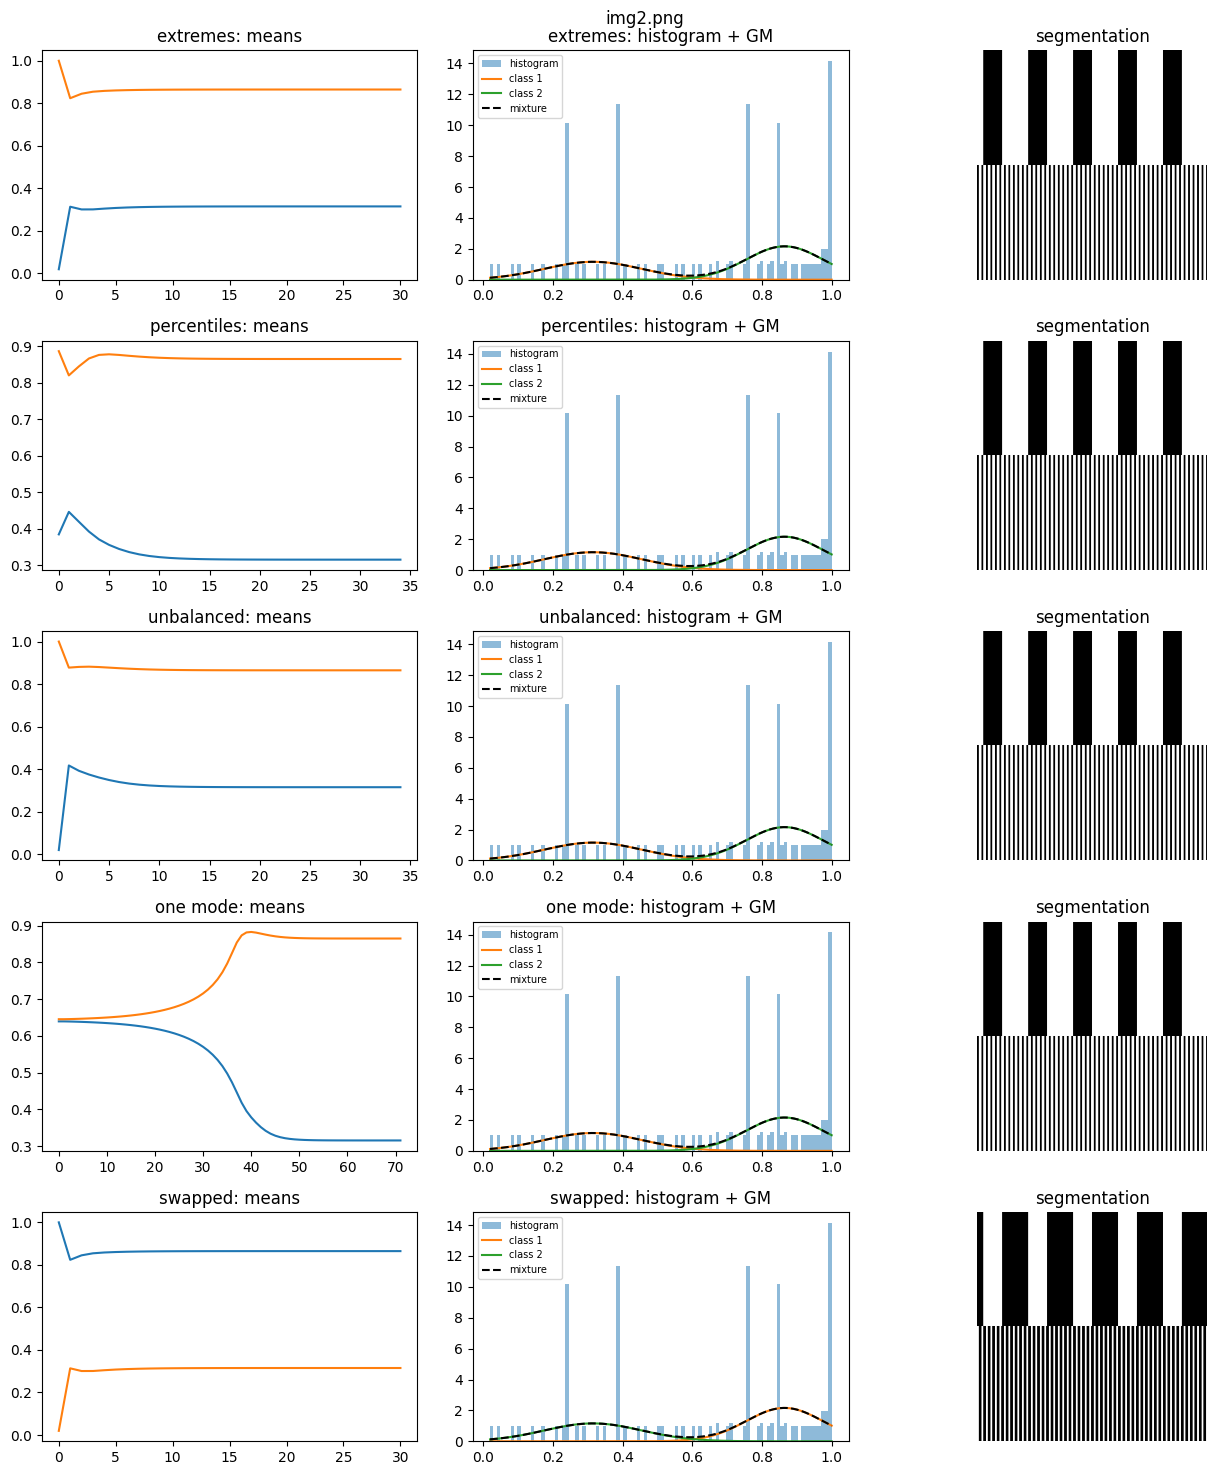

img2.png / percentiles | eps=0.01 | iters=9 | pi=(0.418,0.582) mu=(0.325,0.870) var=(0.0223,0.0112)
img2.png / percentiles | eps=0.0001 | iters=22 | pi=(0.405,0.595) mu=(0.315,0.865) var=(0.0195,0.0121)
img2.png / percentiles | eps=1e-08 | iters=47 | pi=(0.405,0.595) mu=(0.315,0.865) var=(0.0195,0.0121)


In [43]:
for name, img in images.items():
    x = img.reshape(-1)
    m, s2 = x.mean(), x.var()
    inits = {
        'extremes':    [0.5, 0.5, x.min(), x.max(), s2, s2],
        'percentiles': [0.5, 0.5, np.percentile(x, 25), np.percentile(x, 75), s2, s2],
        'unbalanced':  [0.9, 0.1, x.min(), x.max(), s2, s2],
        'one mode':    [0.5, 0.5, m - 0.01*np.sqrt(s2), m + 0.01*np.sqrt(s2), s2, s2],
        'swapped':     [0.5, 0.5, x.max(), x.min(), s2, s2],
    }
    epss = [1e-2, 1e-4, 1e-8]

    g = np.linspace(x.min(), x.max(), 500)          # grid for the pdfs

    fig, axes = plt.subplots(len(inits), 3, figsize=(13, 3*len(inits)))
    for r, (iname, th0) in enumerate(inits.items()):
        hist, lab = run(img, th0, 1e-6, f"{name} / {iname}")
        pi1, pi2, mu1, mu2, v1, v2 = hist[-1]
        f1 = pi1 * pdfGauss(g, mu1, v1)
        f2 = pi2 * pdfGauss(g, mu2, v2)

        # column 0: means vs iterations
        axes[r, 0].plot(hist[:, 2:4]); axes[r, 0].set_title(f'{iname}: means')

        # column 1: histogram + fitted Gaussian mixture
        axes[r, 1].hist(x, bins=100, density=True, alpha=0.5, label='histogram')
        axes[r, 1].plot(g, f1, label='class 1')
        axes[r, 1].plot(g, f2, label='class 2')
        axes[r, 1].plot(g, f1 + f2, 'k--', label='mixture')
        axes[r, 1].set_title(f'{iname}: histogram + GM')
        axes[r, 1].legend(fontsize=7)

        # column 2: segmentation
        axes[r, 2].imshow(lab, cmap='gray'); axes[r, 2].axis('off')
        axes[r, 2].set_title('segmentation')

    fig.suptitle(name); plt.tight_layout(); plt.show()

    # effect of eps (fixed theta0)
    for e in epss:
        run(img, inits['percentiles'], e, f"{name} / percentiles")

#TO DO 6

img3.png (246, 300) min/max: 0.09019608050584793 1.0
img3.png / extremes | eps=1e-06 | iters=10 | pi=(0.679,0.321) mu=(0.261,0.706) var=(0.0010,0.0131)
img3.png / percentiles | eps=1e-06 | iters=12 | pi=(0.679,0.321) mu=(0.261,0.706) var=(0.0010,0.0131)


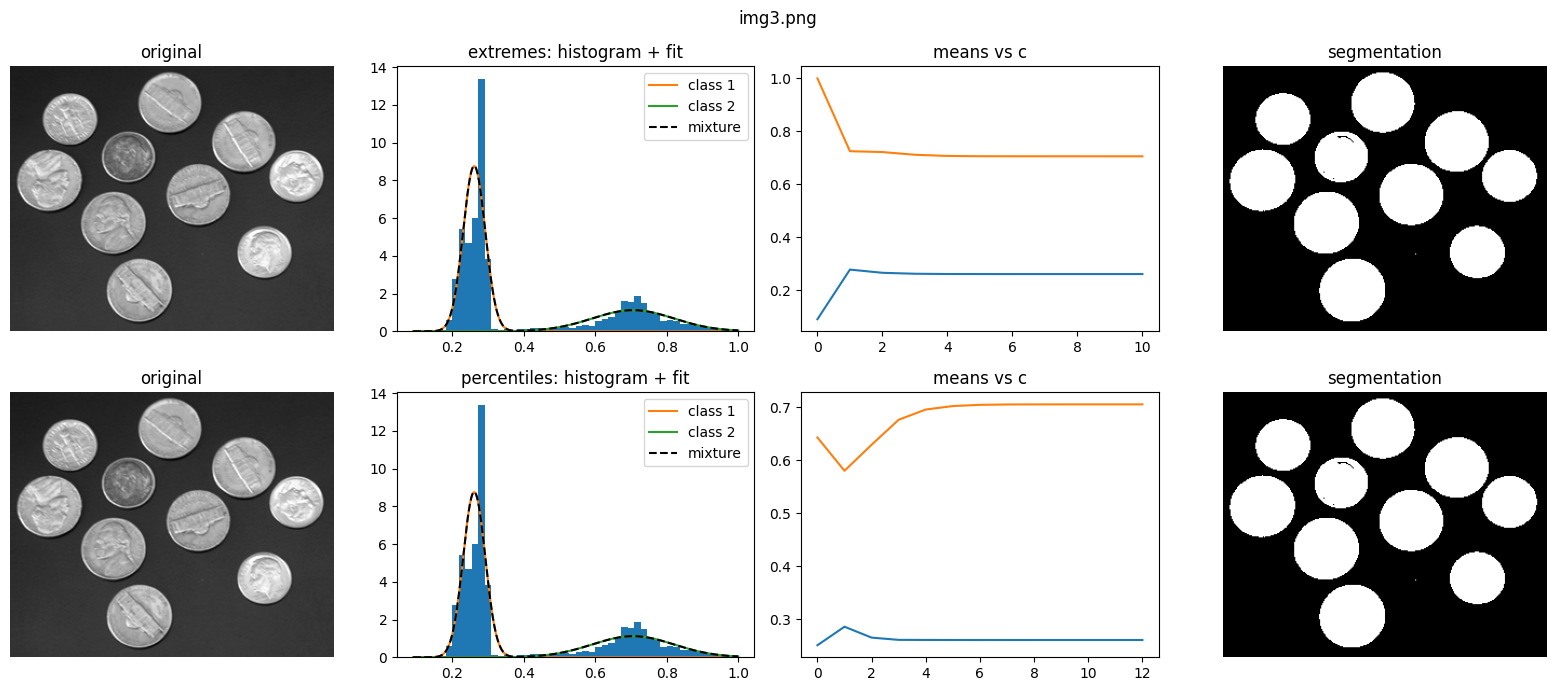

img4.png (225, 225) min/max: 0.0 1.0
img4.png / extremes | eps=1e-06 | iters=74 | pi=(0.209,0.791) mu=(0.054,0.575) var=(0.0008,0.0178)
img4.png / percentiles | eps=1e-06 | iters=75 | pi=(0.209,0.791) mu=(0.054,0.575) var=(0.0008,0.0178)


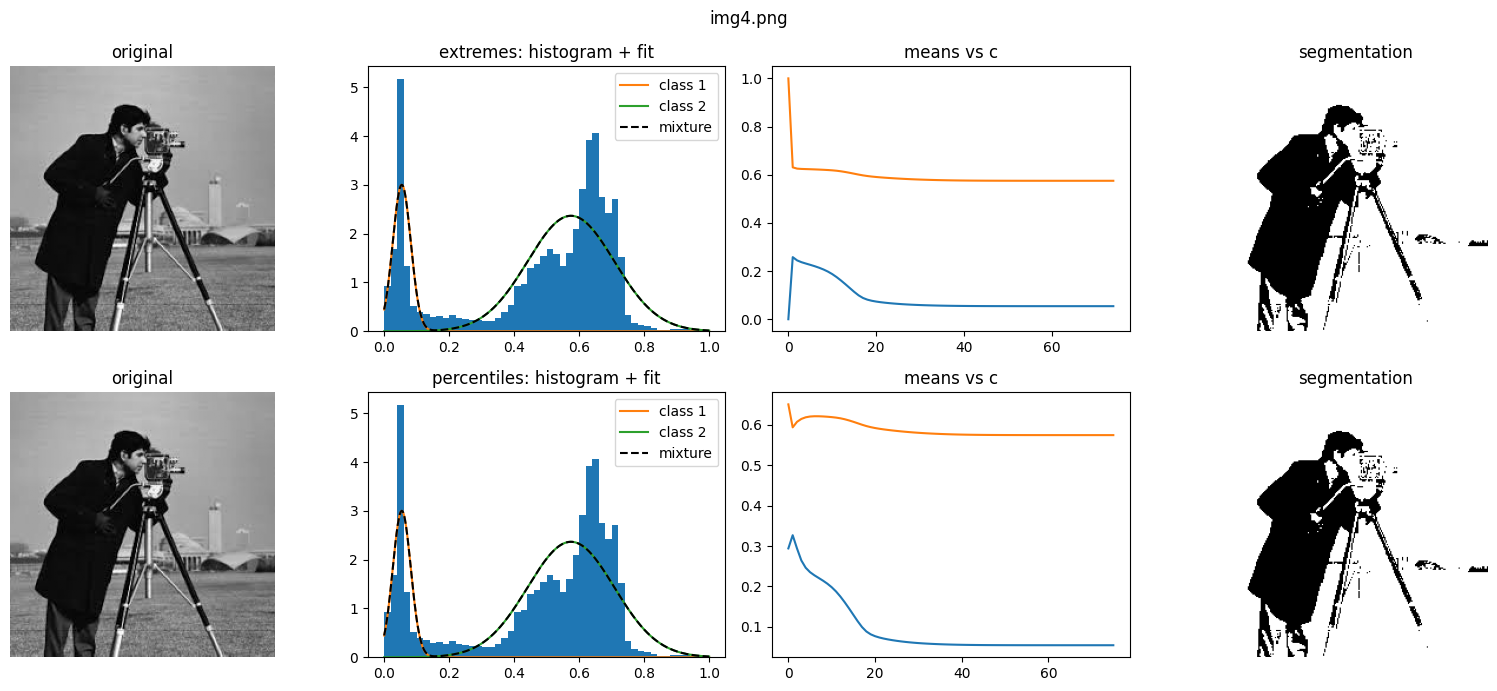

In [44]:
images34 = {'img3.png': load_image('img3.png'),
            'img4.png': load_image('img4.png')}

for name, img in images34.items():
    x = img.reshape(-1)
    s2 = x.var()
    print(name, img.shape, "min/max:", x.min(), x.max())

    inits = {
        'extremes':    [0.5, 0.5, x.min(), x.max(), s2, s2],
        'percentiles': [0.5, 0.5, np.percentile(x, 25), np.percentile(x, 75), s2, s2],
    }

    fig, axes = plt.subplots(len(inits), 4, figsize=(16, 3.5*len(inits)))
    for r, (iname, th0) in enumerate(inits.items()):
        hist, lab = run(img, th0, 1e-6, f"{name} / {iname}")
        pi1, pi2, mu1, mu2, v1, v2 = hist[-1]

        axes[r, 0].imshow(img, cmap='gray'); axes[r, 0].axis('off')
        axes[r, 0].set_title('original')

        # histogram with the fitted mixture superimposed
        g = np.linspace(x.min(), x.max(), 500)
        axes[r, 1].hist(x, bins=50, density=True)
        axes[r, 1].plot(g, pi1*pdfGauss(g, mu1, v1), label='class 1')
        axes[r, 1].plot(g, pi2*pdfGauss(g, mu2, v2), label='class 2')
        axes[r, 1].plot(g, pi1*pdfGauss(g, mu1, v1) + pi2*pdfGauss(g, mu2, v2), 'k--', label='mixture')
        axes[r, 1].set_title(f'{iname}: histogram + fit'); axes[r, 1].legend()

        axes[r, 2].plot(hist[:, 2:4]); axes[r, 2].set_title('means vs c')
        axes[r, 3].imshow(lab, cmap='gray'); axes[r, 3].axis('off')
        axes[r, 3].set_title('segmentation')
    fig.suptitle(name); plt.tight_layout(); plt.show()